In [30]:
#imports 

from torchvision import transforms, models, datasets

# Other imports as necessary

import torch 
import torch.optim as optim 
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader


from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

from torchmetrics.classification import MulticlassAccuracy




In [31]:
# Getting and transforming the images. 

height = 64
width = 64
batch_size = 32

transform = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])


train_dataset = datasets.ImageFolder("data/train", transform=transform)
test_dataset = datasets.ImageFolder("data/test", transform=transform)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Shape of a sample: {train_dataset[0][0].shape}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

mean = 0.0
std = 0.0
total_images = 0

for X, _ in train_loader:
    mean += X.mean()
    std += X.std()
    total_images += 1

mean /= total_images
std /= total_images

print(mean, std)



Number of training samples: 2172
Shape of a sample: torch.Size([1, 64, 64])
tensor(0.3115) tensor(0.2195)


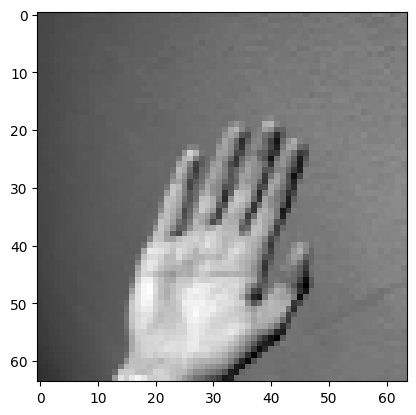

Label of the first image: paper
Highest pixel value in the first image, training: 0.8745098114013672
Lowest pixel value in the first image, training: -0.2862744927406311
Highest pixel value in the first image, testing: 0.7882353067398071
Lowest pixel value in the first image, testing: -0.1294117569923401


In [32]:
#Displaying the first image in the training set.
x_sample = train_dataset[0][0].reshape(height, width)
plt.imshow(x_sample, cmap='gray')
plt.show()
print(f"Label of the first image: {train_dataset.classes[train_dataset[0][1]]}")

print(f"Highest pixel value in the first image, training: {torch.max(train_dataset[0][0])}")
print(f"Lowest pixel value in the first image, training: {torch.min(train_dataset[0][0])}")

print(f"Highest pixel value in the first image, testing: {torch.max(test_dataset[0][0])}")
print(f"Lowest pixel value in the first image, testing: {torch.min(test_dataset[0][0])}")


In [33]:
#Defining the model.
torch.manual_seed(42)

n_features = height * width
n_labels = len(train_dataset.classes)
# print(f"Number of features: {n_features}")
# print(f"Number of labels: {n_labels}")

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_features, 100),
    nn.ReLU(),
    nn.Linear(100, 60),
    nn.ReLU(),
    nn.Linear(60, n_labels) #the output has 10 neurons, corresponding to the 10 possible classes. 
)

In [34]:

#creating the dataloaders. 






train_losses = []
val_losses = []
val_accuracies = []


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


epochs = 50



accuracy = MulticlassAccuracy(num_classes=n_labels).to(device)

for epoch in range(epochs):
    #training 
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        y_pred = model(images)
        
        loss = criterion(y_pred, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    
    #validation 
    model.eval() 
    val_loss = 0
    accuracy.reset()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            y_pred = model(images)
            
            loss += criterion(y_pred, labels)
            val_loss += loss.item()
            
            accuracy.update(y_pred, labels)
    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(accuracy.compute().item())
    
    print(f"Epoch {epoch + 1}/{epochs}: "
          f"Train Loss={train_losses[-1]:.4f}, "
          f"Val Loss={val_losses[-1]:.4f}, "
          f"Val Acc={val_accuracies[-1]:.4f}")

Epoch 1/50: Train Loss=1.0100, Val Loss=8.7360, Val Acc=0.5794
Epoch 2/50: Train Loss=0.8319, Val Loss=7.7110, Val Acc=0.7062
Epoch 3/50: Train Loss=0.6933, Val Loss=7.8121, Val Acc=0.7379
Epoch 4/50: Train Loss=0.5706, Val Loss=6.3457, Val Acc=0.7669
Epoch 5/50: Train Loss=0.4686, Val Loss=6.1417, Val Acc=0.7984
Epoch 6/50: Train Loss=0.4416, Val Loss=5.9700, Val Acc=0.7911
Epoch 7/50: Train Loss=0.3486, Val Loss=4.6949, Val Acc=0.8442
Epoch 8/50: Train Loss=0.3264, Val Loss=3.9729, Val Acc=0.8496
Epoch 9/50: Train Loss=0.2577, Val Loss=3.1011, Val Acc=0.8567
Epoch 10/50: Train Loss=0.2574, Val Loss=3.1809, Val Acc=0.8844
Epoch 11/50: Train Loss=0.2003, Val Loss=3.5328, Val Acc=0.8827
Epoch 12/50: Train Loss=0.2136, Val Loss=2.8178, Val Acc=0.8751
Epoch 13/50: Train Loss=0.1970, Val Loss=3.4172, Val Acc=0.8642
Epoch 14/50: Train Loss=0.1491, Val Loss=3.1888, Val Acc=0.9009
Epoch 15/50: Train Loss=0.1805, Val Loss=4.2575, Val Acc=0.8180
Epoch 16/50: Train Loss=0.1883, Val Loss=3.2105, 

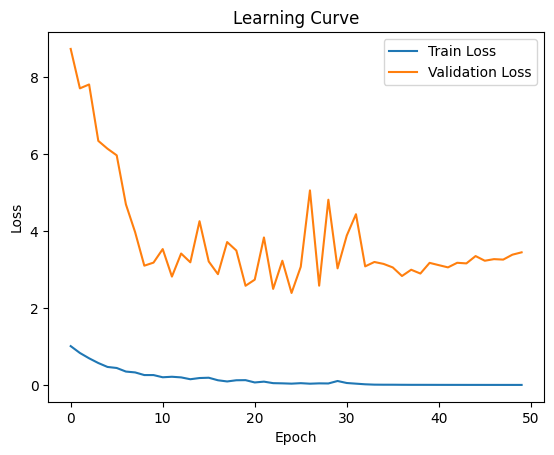

In [37]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.show()

In [36]:
# # Evaluate the model on test data
# model.eval()
# all_preds = []
# all_labels = []

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.to(device)
#         labels = labels.to(device)
        
#         outputs = model(images)
#         _, preds = torch.max(outputs, 1)
        
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# # Generate confusion matrix
# cm = confusion_matrix(all_labels, all_preds)
# print("Confusion Matrix:")
# print(cm)

# # Print classification report
# class_names = test_dataset.classes  # ['paper', 'rock', 'scissors']
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

# # Visualize confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=class_names, yticklabels=class_names)
# plt.title('Confusion Matrix')
# plt.ylabel('True Label')
# plt.xlabel('Predicted Label')
# plt.tight_layout()
# plt.savefig('confusion_matrix.png')
# plt.show()

# # Calculate and print accuracy
# accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
# print(f"\nTest Accuracy: {accuracy:.4f}")

